In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np



In [26]:
# Load the data
df = pd.read_csv('../data/raw/daily_and_month_call_report.csv')

In [3]:
df.head()

,Year,Month,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
0,2025,Feb,155200,98964,3777,5773,3706,42980
1,2025,Jan,130982,87815,3217,4179,3178,32593
2,2024,Dec,133725,86832,3634,3735,3035,36489
3,2024,Nov,153698,93710,3010,4421,4133,48424
4,2024,Oct,214604,108207,6307,5792,8885,80804


In [4]:
# Check for missing values
df.isnull().sum()

Year                                         0
Month                                        0
Total Number of Calls                        0
Total Number of Doctors Consultancy          0
Number of Total Health Information           0
Number of Total Ambulance Information        0
Number of Total Complaints                   0
Number of Calls To Know About The Service    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Year                                       107 non-null    int64 
 1   Month                                      107 non-null    object
 2   Total Number of Calls                      107 non-null    int64 
 3   Total Number of Doctors Consultancy        107 non-null    int64 
 4   Number of Total Health Information         107 non-null    int64 
 5   Number of Total Ambulance Information      107 non-null    int64 
 6   Number of Total Complaints                 107 non-null    int64 
 7   Number of Calls To Know About The Service  107 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 6.8+ KB


In [6]:
# Check month names
df['Month'].unique()

array(['Feb', 'Jan', 'Dec', 'Nov', 'Oct', 'Sept', 'Aug', 'July', 'June',
       'May', 'Apr', 'Mar'], dtype=object)

In [7]:
# Standardize non-standard month names
df['Month'] = df['Month'].str.replace('Sept', 'Sep').str.replace('July', 'Jul').str.replace('June', 'Jun')

In [8]:
df['Month'].unique()

array(['Feb', 'Jan', 'Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 'Jun',
       'May', 'Apr', 'Mar'], dtype=object)

In [9]:
# Create datetime object
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')

In [10]:
# Set Date as index and sort oldest to newest
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

In [11]:
df.columns

Index(['Year', 'Month', 'Total Number of Calls',
       'Total Number of Doctors Consultancy',
       'Number of Total Health Information',
       'Number of Total Ambulance Information', 'Number of Total Complaints',
       'Number of Calls To Know About The Service'],
      dtype='object')

In [12]:
# Drop redundant columns and rename columns for clarity
df.drop(columns=['Year', 'Month'], inplace=True)
df.rename(columns={'Total Number of Calls': 'total_calls',
       'Total Number of Doctors Consultancy': 'total_doctor_consults',
       'Number of Total Health Information': 'health_info',
       'Number of Total Ambulance Information': 'ambulance_info', 
       'Number of Total Complaints': "complaints",
       'Number of Calls To Know About The Service': 'service_info'}, inplace=True)    

In [13]:
df.head()

,total_calls,total_doctor_consults,health_info,ambulance_info,complaints,service_info
Date,,,,,,
2016-04-01,51432,43885,3175,220,77,4075
2016-05-01,166635,137326,12118,925,439,15827
2016-06-01,186433,152580,14887,856,473,17637
2016-07-01,145061,116686,11831,922,404,15218
2016-08-01,142400,112831,12184,980,340,16065


### Signal vs. Strain
We're starting by looking at the 2019 dengue outbreak, as opposed to the COVID-19 outbreak, because it was a typical outbreak with a clear beginning, peak, and end. It makes a good test case to see if there is temporal lag. COVID-19, on the other hand, lasted for years and involved multiple waves. 

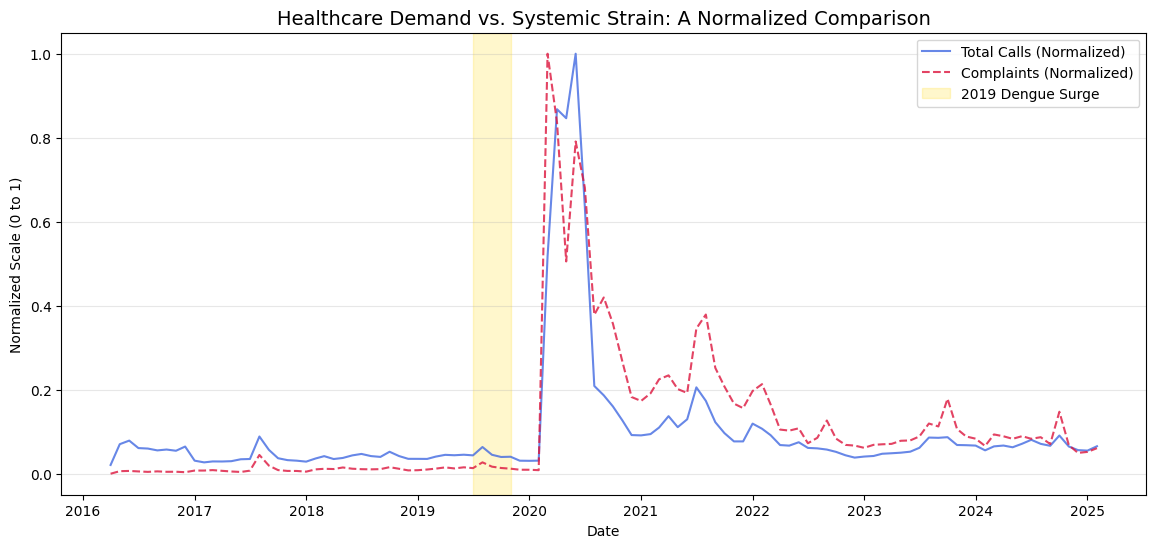

In [14]:

plt.figure(figsize=(14, 6))

# Normalizing to see the relationship clearly between total calls and complaints
plt.plot(df.index, df['total_calls'] / df['total_calls'].max(), 
         label='Total Calls (Normalized)', color='royalblue', alpha=0.8)
plt.plot(df.index, df['complaints'] / df['complaints'].max(), 
         label='Complaints (Normalized)', color='crimson', linestyle='--', alpha=0.8)

# Highlight the 2019 Dengue period
plt.axvspan('2019-07-01', '2019-11-01', color='gold', alpha=0.2, label='2019 Dengue Surge')

plt.title('Healthcare Demand vs. Systemic Strain: A Normalized Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Scale (0 to 1)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

*No obvious lag is apparent in the comparison plot of calls and complaints, so we'll zoom in.*

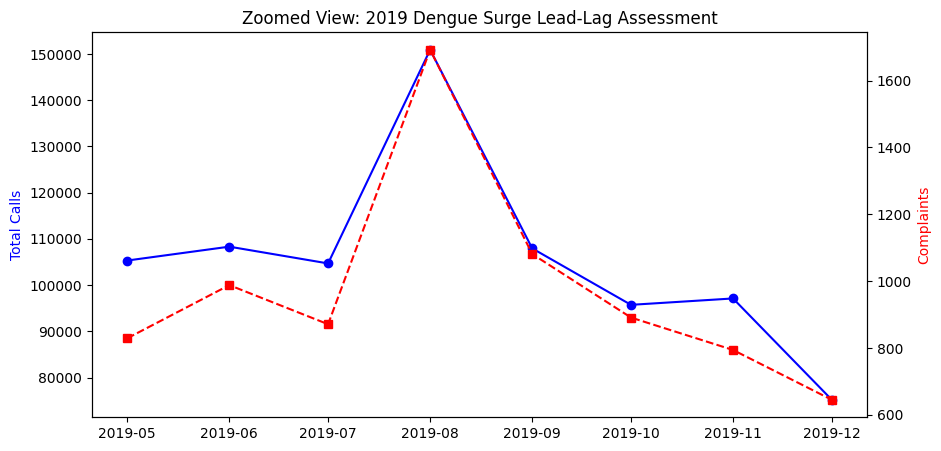

In [15]:
# Zooming in on the 2019 Dengue Outbreak
dengue_surge = df.loc['2019-05-01':'2019-12-01']

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(dengue_surge.index, dengue_surge['total_calls'], color='blue', marker='o', label='Calls')
ax1.set_ylabel('Total Calls', color='blue')

ax2 = ax1.twinx()
ax2.plot(dengue_surge.index, dengue_surge['complaints'], color='red', marker='s', label='Complaints', linestyle='--')
ax2.set_ylabel('Complaints', color='red')

plt.title('Zoomed View: 2019 Dengue Surge Lead-Lag Assessment')
plt.show()

*It still doesn't look like there is a lag. Next we'll use cross-correlation to confirm that the lag is actually 0.*

In [16]:
# Calculate Cross-Correlation between Calls and Complaints
# 'lags=6' looks at a 6-month window
ccf_values = sm.tsa.stattools.ccf(df['complaints'], df['total_calls'], adjusted=False)

# Print the first few lags
for i in range(5):
    print(f"Correlation at Lag {i}: {ccf_values[i]:.3f}")

Correlation at Lag 0: 0.871
Correlation at Lag 1: 0.717
Correlation at Lag 2: 0.598
Correlation at Lag 3: 0.514
Correlation at Lag 4: 0.376


*The highest correlation is at Lag 0, suggesting that systemic complaints rise contemporaneously with call volume. This indicates that the infrustructure experiences immediate pressure during public health emergencies, rather than a delayed effect, when using a 1-month resolution.* 

In [17]:
# Calculate Cross-Correlation between Doctor Consults and Complaints
# 'lags=6' looks at a 6-month window
ccf_values = sm.tsa.stattools.ccf(df['complaints'], df['total_doctor_consults'], adjusted=False)

# Print the first few lags
for i in range(5):
    print(f"Correlation at Lag {i}: {ccf_values[i]:.3f}")

Correlation at Lag 0: 0.827
Correlation at Lag 1: 0.689
Correlation at Lag 2: 0.576
Correlation at Lag 3: 0.487
Correlation at Lag 4: 0.352


*Checked complaints against doctor consults in case the lag is hidden in the noise of total calls. However, the pattern of correlations is similar to total calls.*

In [18]:
# Check if calls lag complaints (negative shift)
for i in range(-3, 1):
    corr = df['complaints'].corr(df['total_calls'].shift(i))
    print(f"Correlation at Lag {i}: {corr:.3f}")

Correlation at Lag -3: 0.482
Correlation at Lag -2: 0.628
Correlation at Lag -1: 0.791
Correlation at Lag 0: 0.871


*Checked for negative lag, but because the correlation coefficient peaks perfectly at Lag 0 (0.871) and drops as you move away in either direction (positive or negative), we have clear statistical evidence that demand and strain are contemporaneous at the monthly level.*

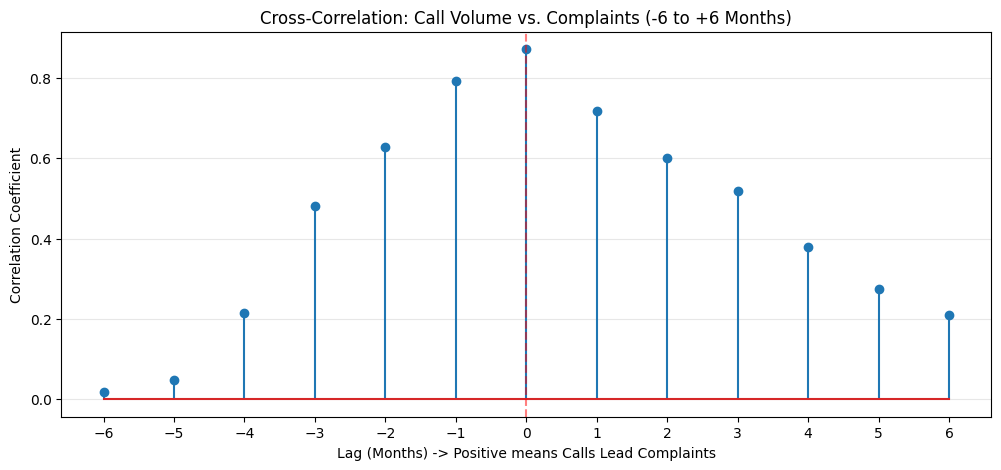

Lag -6: 0.018
Lag -5: 0.047
Lag -4: 0.216
Lag -3: 0.482
Lag -2: 0.628
Lag -1: 0.791
Lag 0: 0.871
Lag 1: 0.718
Lag 2: 0.601
Lag 3: 0.518
Lag 4: 0.379
Lag 5: 0.274
Lag 6: 0.208


In [19]:
# Calculate CCF for both positive and negative lags

lags = np.arange(-6, 7)
corrs = []

for lag in lags:
    # Shift the 'total_calls' series and correlate with 'complaints'
    c = df['complaints'].corr(df['total_calls'].shift(lag))
    corrs.append(c)

# Plot the CCF
plt.figure(figsize=(12, 5))
plt.stem(lags, corrs)
plt.axvline(0, color='red', linestyle='--', alpha=0.5) # The Zero Line
plt.title('Cross-Correlation: Call Volume vs. Complaints (-6 to +6 Months)')
plt.xlabel('Lag (Months) -> Positive means Calls Lead Complaints')
plt.ylabel('Correlation Coefficient')
plt.xticks(lags)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print results for documentation
for lag, corr in zip(lags, corrs):
    print(f"Lag {lag}: {corr:.3f}")

*The significant correlation at negative lags (e.g., Lag -1: 0.791) suggests that systemic strain begins to manifest during the initial uptick of a surge, rather than only at the peak. However, the global maximum at Lag 0 confirms that the strongest alignment between demand and strain occurs contemporaneously within the same monthly window.*

### Structural Break Analysis

In [20]:
# Create a 'Pre-COVID' and 'During-COVID' slice
pre_covid = df.loc[:'2020-02-01']
during_covid = df.loc['2020-03-01':'2022-12-01']

print(f"Pre-COVID Correlation: {pre_covid['total_calls'].corr(pre_covid['complaints']):.3f}")
print(f"During-COVID Correlation: {during_covid['total_calls'].corr(during_covid['complaints']):.3f}")

Pre-COVID Correlation: 0.451
During-COVID Correlation: 0.867


In [21]:
# Decompose both total calls and complaints to isolate the "shocks" (residuals)
res_calls = seasonal_decompose(df['total_calls'], model='additive').resid.dropna()
res_comp = seasonal_decompose(df['complaints'], model='additive').resid.dropna()

# Check correlation of the "shocks" only
print(f"Residual Correlation: {res_calls.corr(res_comp):.3f}")

Residual Correlation: 0.787


*The residual correlation is very strong, meaning...*

    - The Magnitude: Since 1.0 is a perfect 1-to-1 match, 0.787 means that nearly 80% of the "unpredictable" spikes in calls are mirrored exactly by a spike in complaints.
    - The Timing (Lag 0): This means the complaints aren't waiting for the surge to finish. They are happening in the same month the surge begins.
    - The Conclusion: In a healthy system, you might see a small surge and a delayed or low correlation in complaints because the system has a buffer, such as extra staff. In this data, the high correlation at Lag 0 proves there is no buffer. The system is likely already at its limit, so any "shock" translates instantly into a failure in service quality.

In [22]:
# Check stationarity of the complaints time series

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')

check_stationarity(df['total_calls'])
check_stationarity(df['complaints'])

ADF Statistic: -2.235
p-value: 0.194
ADF Statistic: -3.008
p-value: 0.034


In [23]:
# Create a differenced series
df['calls_diff'] = df['total_calls'].diff().dropna()

# Check stationarity again
check_stationarity(df['calls_diff'].dropna())

ADF Statistic: -5.669
p-value: 0.000


In [24]:
# Create a 'Pre-COVID' and 'During-COVID' slice
pre_covid = df.loc[:'2020-02-01']
during_covid = df.loc['2020-03-01':'2022-12-01']

print(f"Pre-COVID Correlation: {pre_covid['total_calls'].corr(pre_covid['complaints']):.3f}")
print(f"During-COVID Correlation: {during_covid['total_calls'].corr(during_covid['complaints']):.3f}")

Pre-COVID Correlation: 0.451
During-COVID Correlation: 0.867


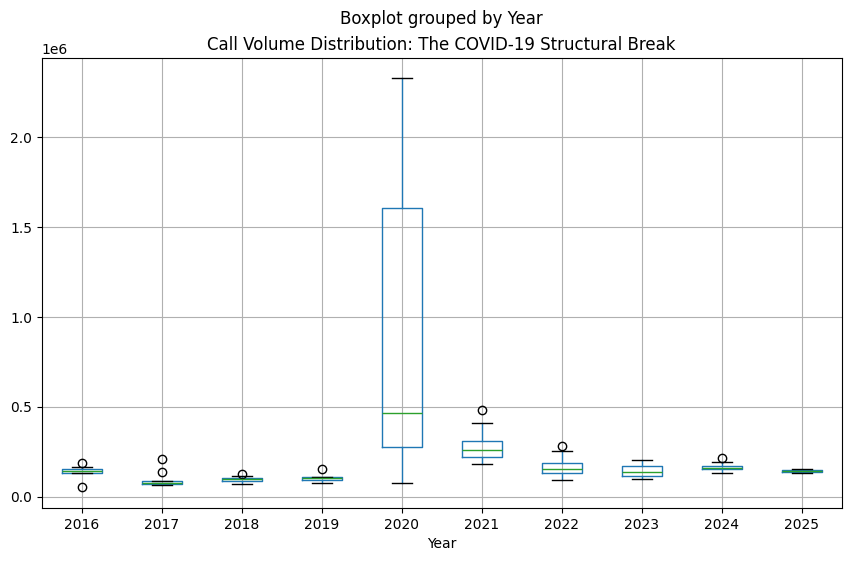

In [25]:
# Boxplot of call volume by year

df['Year'] = df.index.year
df.boxplot(column='total_calls', by='Year', figsize=(10,6))
plt.title('Call Volume Distribution: The COVID-19 Structural Break')
plt.show()

### **Summary of Statistical Findings: Demand vs. Strain**

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Total Correlation** | 0.871 | Strong overall alignment of demand and strain across the 10-year period. |
| **Residual Correlation** | 0.787 | High correlation of "unpredictable shocks," indicating immediate system pressure. |
| **Peak Lag** | 0 | Both predictable and unpredictable events trigger contemporaneous strain. |
| **Stationarity (Calls)** | p = 0.000 | Achieved stationarity through first-order differencing ($d=1$). |